# Bayesian old-model special subjects

Fit selected subjects with the old `src.Bayesian` model code.

Default target: `sub321` with `M6_MH`, modeled after `notebooks/Bayesian_meg.ipynb`.

## 1. Initialize

In [1]:
import os
import sys
from pathlib import Path
import logging

import joblib
import numexpr
import numpy as np
import pandas as pd

numexpr.set_num_threads(64)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
logger = logging.getLogger(__name__)

# Works both when the notebook cwd is repo root and when it is notebooks/.
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
if not (project_root / 'src' / 'Bayesian').exists():
    raise FileNotFoundError(f'Cannot locate src/Bayesian from project_root={project_root}')

sys.path.insert(0, str(project_root))
print(f'project_root = {project_root}')

from src.Bayesian import *
from src.Bayesian.problems import *
from src.Bayesian.problems.config import config_fgt
from src.Bayesian.problems.fit_config import (
    window_size_configs,
    module_configs_M3,
    module_configs_M5,
    module_configs_M6,
    module_configs_M7,
)
from src.Bayesian.utils.optimizer import Optimizer, ConstantDict
from src.Bayesian.utils.model_evaluation import ModelEval

# Edit these if needed.
subIDs = [321]
model_name = 'M6_MH'
n_jobs = 120
processed_path = project_root / 'data' / 'processed' / 'Task2_processed.csv'
result_path = project_root / 'results' / 'model_results_special_subjects' / 'Model_results_sub321_old_bayesian'
result_path.mkdir(parents=True, exist_ok=True)

if model_name == 'M0_Base':
    module_configs = {}
elif model_name == 'M1_P':
    module_configs = {'perception': (BasePerception, {})}
elif model_name == 'M2_M':
    module_configs = {
        'memory': (BaseMemory, {
            'personal_memory_range': {'gamma': (0.05, 1.0), 'w0': (0.075, 0.15)},
            'param_resolution': 20,
        })
    }
elif model_name == 'M3_H':
    module_configs = module_configs_M3
elif model_name == 'M4_PM':
    module_configs = {
        'memory': (BaseMemory, {
            'personal_memory_range': {'gamma': (0.05, 1.0), 'w0': (0.075, 0.15)},
            'param_resolution': 20,
        }),
        'perception': (BasePerception, {}),
    }
elif model_name == 'M5_PH':
    module_configs = module_configs_M5
elif model_name == 'M6_MH':
    module_configs = module_configs_M6
elif model_name == 'M7_PMH':
    module_configs = module_configs_M7
else:
    raise ValueError(f'Unknown model_name: {model_name}')

optimizer = Optimizer(module_configs, n_jobs=n_jobs)
optimizer.prepare_data(processed_path)

learning_df = optimizer.learning_data.copy()
missing_subjects = [sid for sid in subIDs if sid not in set(learning_df['iSub'].unique())]
if missing_subjects:
    raise ValueError(f'Missing subjects in {processed_path}: {missing_subjects}')

print(f'processed_path = {processed_path}')
print(f'result_path = {result_path}')
print(learning_df[learning_df['iSub'].isin(subIDs)].groupby(['iSub', 'condition']).size())
print({sid: window_size_configs[sid] for sid in subIDs})

2026-06-02 10:47:34 - INFO - logger is running normally.


project_root = /data2/yangjiong/CategoryLearning_gitcode
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104734.log
Using parallel optimization for multiple subjects.
processed_path = /data2/yangjiong/CategoryLearning_gitcode/data/processed/Task2_processed.csv
result_path = /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian
iSub  condition
321   3            768
dtype: int64
{321: 16}


## 2. Fit model

In [2]:
# Same M6_MH budget pattern as Bayesian_meg.ipynb.
# Reduce these first if you want a quick smoke test.
grid_repeat = 64
mc_samples = 1024
stop_at = 1.0

if model_name == 'M0_Base':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 1, 0, stop_at=stop_at)
elif model_name == 'M1_P':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 0, 500, stop_at=stop_at)
elif model_name == 'M2_M':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 1, 0, stop_at=stop_at)
elif model_name == 'M3_H':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 0, 1000, stop_at=stop_at)
elif model_name == 'M4_PM':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 3, 500, stop_at=stop_at)
elif model_name == 'M5_PH':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 0, 1000, stop_at=stop_at)
elif model_name == 'M6_MH':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, grid_repeat, mc_samples, stop_at=stop_at)
elif model_name == 'M7_PMH':
    res = optimizer.optimize_params_with_subs_parallel(config_fgt, subIDs, window_size_configs, 5, 1000, stop_at=stop_at)

optimizer.save_results(res, model_name, result_path)
res

Processing tasks:  30%|████████████▉                              | 120/400 [00:01<00:03, 88.54it/s]

/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log


INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104736.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104737.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104737.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104737.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104737.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_104737.log


INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


...

/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163424.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163424.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163424.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log


INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.
INFO:cat-learning:logger is running normally.


/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163425.log
/data2/yangjiong/CategoryLearning_gitcode/logs/Run_20260602_163428.log


INFO:cat-learning:logger is running normally.
Computing error for params: 100%|██████████| 1024/1024 [13:10<00:00,  1.29it/s]
2026-06-02 16:49:42 - INFO - Results saved to /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH.joblib


{321: {'condition': np.int64(3),
  'best_params': {'gamma': np.float64(0.15), 'w0': 0.007894736842105263},
  'best_error': np.float64(0.11153397389446287),
  'best_step_results': [{'best_k': 64,
    'best_beta': np.float64(30.0),
    'best_params': {'k': 64,
     'beta': np.float64(30.0),
     'gamma': np.float64(0.15),
     'w0': 0.007894736842105263},
    'best_log_likelihood': np.float64(-0.0007397201010319212),
    'best_norm_posterior': np.float64(0.3098090956748268),
    'hypo_details': {64: {'beta_opt': np.float64(30.0),
      'll_max': np.float64(-0.0007397201010319212),
      'post_max': np.float64(0.3098090956748268),
      'is_best': True},
     68: {'beta_opt': np.float64(1.0),
      'll_max': np.float64(-16.11809565095832),
      'post_max': np.float64(3.1003835247285645e-08),
      'is_best': False},
     37: {'beta_opt': np.float64(1.0),
      'll_max': np.float64(-16.11809565095832),
      'post_max': np.float64(3.1003835247285645e-08),
      'is_best': False},
     13:

## 3. Predict choices and probabilities

In [3]:
res = optimizer.load_results(result_path / f'{model_name}.joblib')
optimizer.set_results(res)

prediction = optimizer.predict_with_subs_parallel(config_fgt, subIDs, window_size=window_size_configs)
joblib.dump(prediction, result_path / f'{model_name}_prediction.joblib')

prediction_probs = optimizer.predict_probs_with_subs_parallel(config_fgt, subIDs, window_size=window_size_configs)
joblib.dump(prediction_probs, result_path / f'{model_name}_prediction_probs.joblib')

print(f'Saved prediction files in {result_path}')
prediction_probs[subIDs[0]].keys()

2026-06-02 16:49:43 - INFO - Results loaded from /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH.joblib
Predicting tasks: 100%|██████████████████████████████████████████████| 1/1 [00:00<00:00, 994.85it/s]


Saved prediction files in /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian


dict_keys(['condition', 'true_choice', 'pred_choice', 'top1_choice', 'pred_probs', 'true_acc', 'pred_acc', 'sliding_true_acc', 'sliding_pred_acc', 'sliding_pred_acc_std', 'original_posterior', 'choice_constrained_posterior', 'original_true_choice_prob', 'cc_true_choice_prob', 'posterior_shift_tv'])

## 4. Quick summary

In [4]:
summary_rows = []
for sid in subIDs:
    fit = res[sid]
    pred = prediction_probs[sid]
    summary_rows.append({
        'iSub': sid,
        'condition': fit.get('condition'),
        'window_size': window_size_configs[sid],
        'best_params': fit.get('best_params'),
        'best_error': fit.get('best_error'),
        'mean_sample_error': float(np.mean(fit.get('sample_errors', [np.nan]))),
        'true_acc_mean': float(np.nanmean(pred.get('true_acc', [np.nan]))),
        'pred_acc_mean': float(np.nanmean(pred.get('pred_acc', [np.nan]))),
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = result_path / f'{model_name}_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print(f'Saved {summary_csv}')
summary_df

Saved /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_summary.csv


,iSub,condition,window_size,best_params,best_error,mean_sample_error,true_acc_mean,pred_acc_mean
0,321,3,16,"{'gamma': 0.15, 'w0': 0.007894736842105263}",0.111534,0.147686,0.559896,0.547955


## 5. Export trial-level prediction table

In [5]:
def posterior_entropy(posterior, eps=1e-12):
    if not isinstance(posterior, dict) or len(posterior) == 0:
        return np.nan
    values = np.asarray(list(posterior.values()), dtype=float)
    values = np.clip(values, eps, None)
    values = values / values.sum()
    return float(-np.sum(values * np.log(values)))

def top1_probability(posterior):
    if not isinstance(posterior, dict) or len(posterior) == 0:
        return np.nan
    return float(max(posterior.values()))

def top1_hypothesis(posterior):
    if not isinstance(posterior, dict) or len(posterior) == 0:
        return np.nan
    return max(posterior, key=posterior.get)

def posterior_to_json(posterior):
    if not isinstance(posterior, dict):
        return None
    return json.dumps({str(k): float(v) for k, v in posterior.items()}, ensure_ascii=False, sort_keys=True)

import json

for sid in subIDs:
    subject_df = learning_df[learning_df['iSub'] == sid].copy().reset_index(drop=True)
    pred = prediction_probs[sid]
    n = len(pred['pred_choice'])
    subject_df = subject_df.iloc[:n].copy().reset_index(drop=True)

    probs = np.asarray(pred['pred_probs'], dtype=float)
    out = pd.DataFrame({
        'iSub': sid,
        'trial': np.arange(1, n + 1),
        'condition': subject_df['condition'].to_numpy(),
        'choice': subject_df['choice'].to_numpy(),
        'category': subject_df['category'].to_numpy(),
        'feedback': subject_df['feedback'].to_numpy(),
        'rating': subject_df['rating'].to_numpy() if 'rating' in subject_df.columns else np.nan,
        'pred_choice': np.asarray(pred['pred_choice']),
        'top1_choice': np.asarray(pred['top1_choice']),
        'true_acc': np.asarray(pred['true_acc'], dtype=float),
        'pred_acc': np.asarray(pred['pred_acc'], dtype=float),
        'original_true_choice_prob': np.asarray(pred.get('original_true_choice_prob', np.full(n, np.nan)), dtype=float),
        'cc_true_choice_prob': np.asarray(pred.get('cc_true_choice_prob', np.full(n, np.nan)), dtype=float),
        'posterior_shift_tv': np.asarray(pred.get('posterior_shift_tv', np.full(n, np.nan)), dtype=float),
    })

    for choice_idx in range(probs.shape[1]):
        out[f'pred_prob_choice_{choice_idx + 1}'] = probs[:, choice_idx]

    original_post = pred.get('original_posterior', [None] * n)
    cc_post = pred.get('choice_constrained_posterior', [None] * n)
    out['origin_entropy'] = [posterior_entropy(x) for x in original_post]
    out['origin_top1_hypothesis'] = [top1_hypothesis(x) for x in original_post]
    out['origin_top1_probability'] = [top1_probability(x) for x in original_post]
    out['choice_constrained_entropy'] = [posterior_entropy(x) for x in cc_post]
    out['choice_constrained_top1_hypothesis'] = [top1_hypothesis(x) for x in cc_post]
    out['choice_constrained_top1_probability'] = [top1_probability(x) for x in cc_post]
    out['origin_posterior_json'] = [posterior_to_json(x) for x in original_post]
    out['choice_constrained_posterior_json'] = [posterior_to_json(x) for x in cc_post]

    csv_path = result_path / f'{model_name}_sub{sid}_trial_predictions.csv'
    out.to_csv(csv_path, index=False)
    print(f'Saved {csv_path} with shape={out.shape}')

display(out.head())

Saved /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_sub321_trial_predictions.csv with shape=(768, 26)


,iSub,trial,condition,choice,category,feedback,rating,pred_choice,top1_choice,true_acc,...,pred_prob_choice_3,pred_prob_choice_4,origin_entropy,origin_top1_hypothesis,origin_top1_probability,choice_constrained_entropy,choice_constrained_top1_hypothesis,choice_constrained_top1_probability,origin_posterior_json,choice_constrained_posterior_json
0,321,1,3,4,3,0.5,NaN,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
1,321,2,3,3,2,0.0,NaN,3,3,0.0,...,0.711970,0.102793,1.717576,64.0,0.309809,NaN,NaN,NaN,"{""111"": 0.07882188032288306, ""13"": 0.077498313...",None
2,321,3,3,3,3,1.0,NaN,1,1,1.0,...,0.244311,0.217758,2.427557,6.0,0.116430,2.432831,48.0,0.160296,"{""11"": 0.08636165414712536, ""110"": 0.084647652...","{""11"": 0.050677494770575086, ""110"": 0.08661681..."
3,321,4,3,1,1,1.0,NaN,1,1,1.0,...,0.132515,0.102038,2.324923,25.0,0.215763,NaN,NaN,NaN,"{""113"": 0.05273884165789333, ""17"": 0.052743916...",None
4,321,5,3,2,3,0.0,NaN,4,4,0.0,...,0.256402,0.483811,1.728056,67.0,0.263435,0.817279,79.0,0.758409,"{""110"": 0.20569799644450024, ""15"": 0.075707694...","{""110"": 0.016671249935947426, ""15"": 0.14645810..."


## 6. Diagnostic plots

2026-06-02 16:49:44 - INFO - Posterior Probabilities for k by Subject saved to /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_posterior.png
2026-06-02 16:49:45 - INFO - Grid Search Error by Subject saved to /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_grid.png
2026-06-02 16:49:45 - INFO - Strategy Amount by Subject saved to /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_amount.png
2026-06-02 16:49:45 - INFO - Predicted vs True Accuracy by Subject saved to /data2/yangjiong/CategoryLearning_gitcode/results/model_results_special_subjects/Model_results_sub321_old_bayesian/M6_MH_accuracy.png


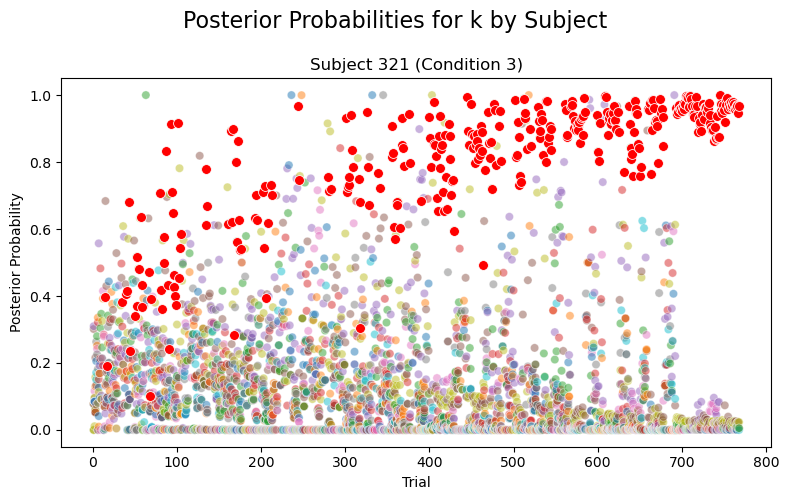

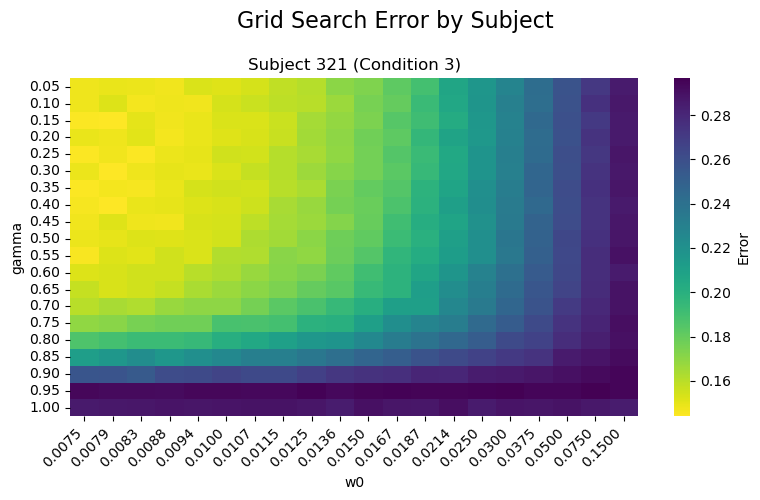

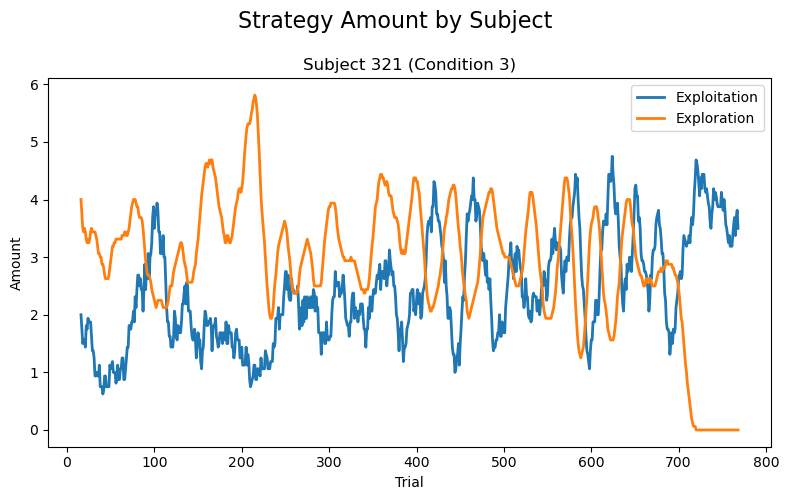

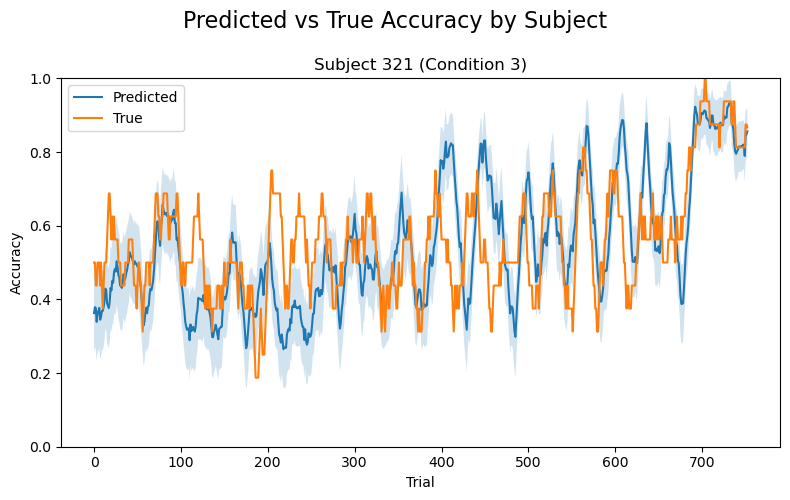

In [6]:
model_eval = ModelEval()

model_eval.plot_posterior_probabilities(
    res,
    subjects=subIDs,
    save_path=result_path / f'{model_name}_posterior.png',
)

if model_name in ['M2_M', 'M4_PM', 'M6_MH', 'M7_PMH']:
    model_eval.plot_error_grids(
        res,
        subjects=subIDs,
        fname=['gamma', 'w0'],
        save_path=result_path / f'{model_name}_grid.png',
    )

if model_name in ['M3_H', 'M5_PH', 'M6_MH', 'M7_PMH']:
    model_eval.plot_cluster_amount(
        res,
        subjects=subIDs,
        window_size=window_size_configs[subIDs[0]],
        save_path=result_path / f'{model_name}_amount.png',
    )

model_eval.plot_accuracy_comparison(
    prediction,
    subjects=subIDs,
    save_path=result_path / f'{model_name}_accuracy.png',
)